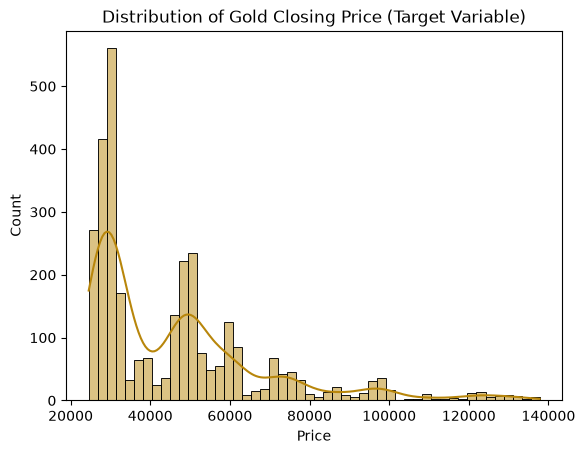

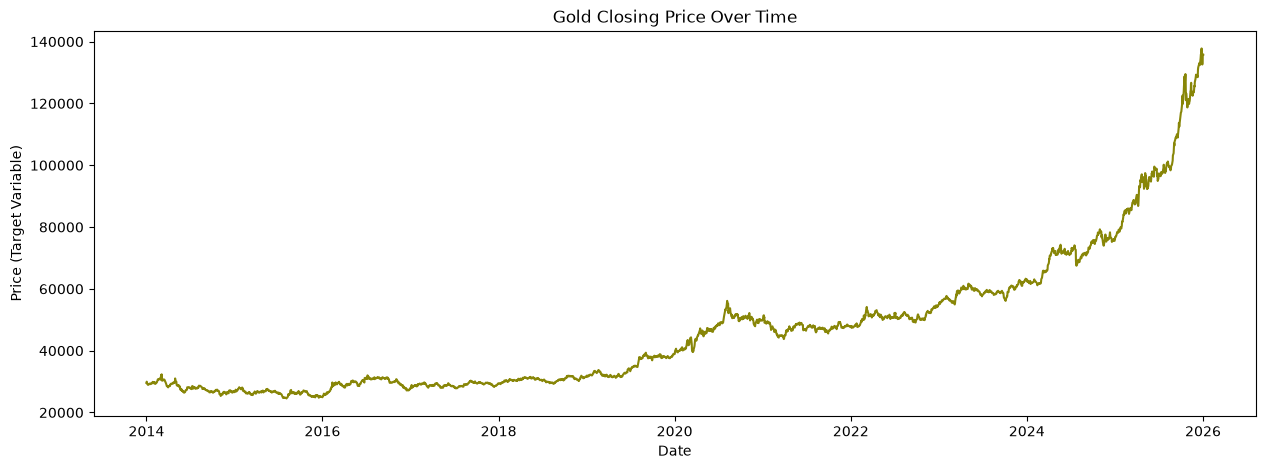

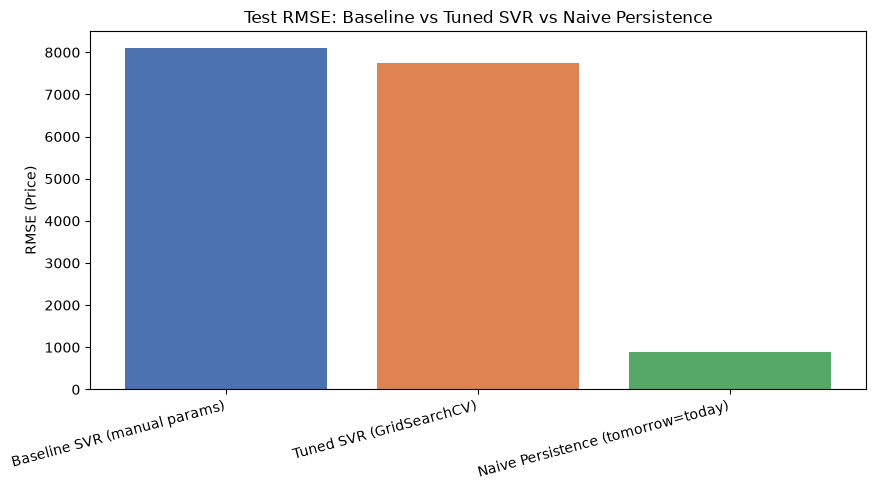

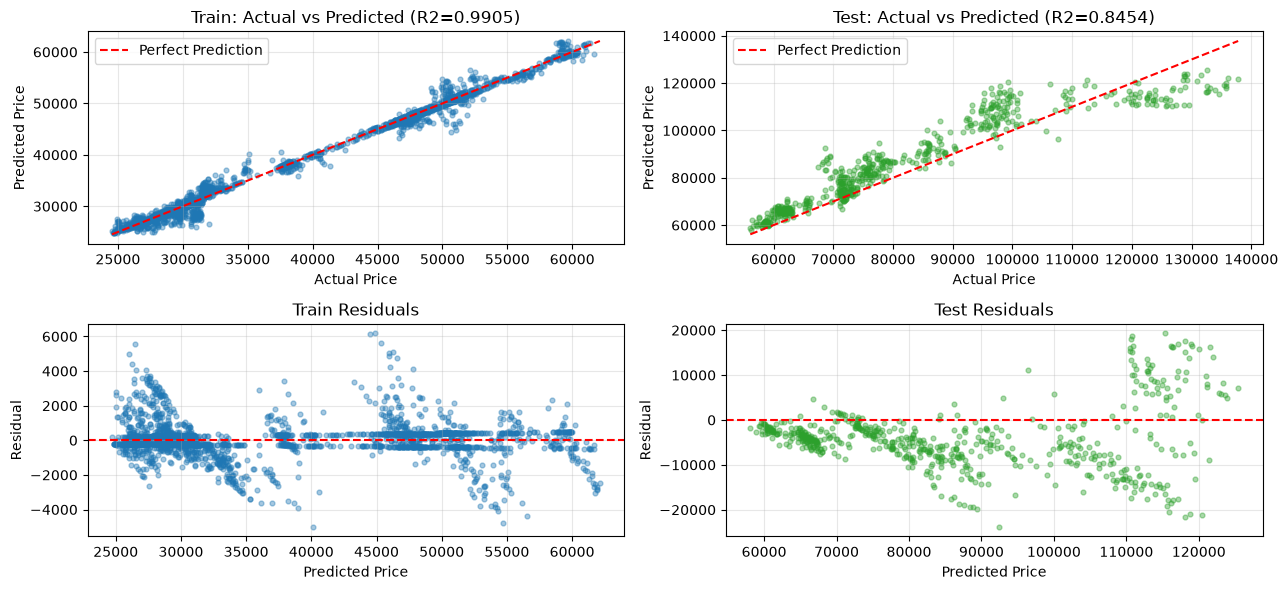

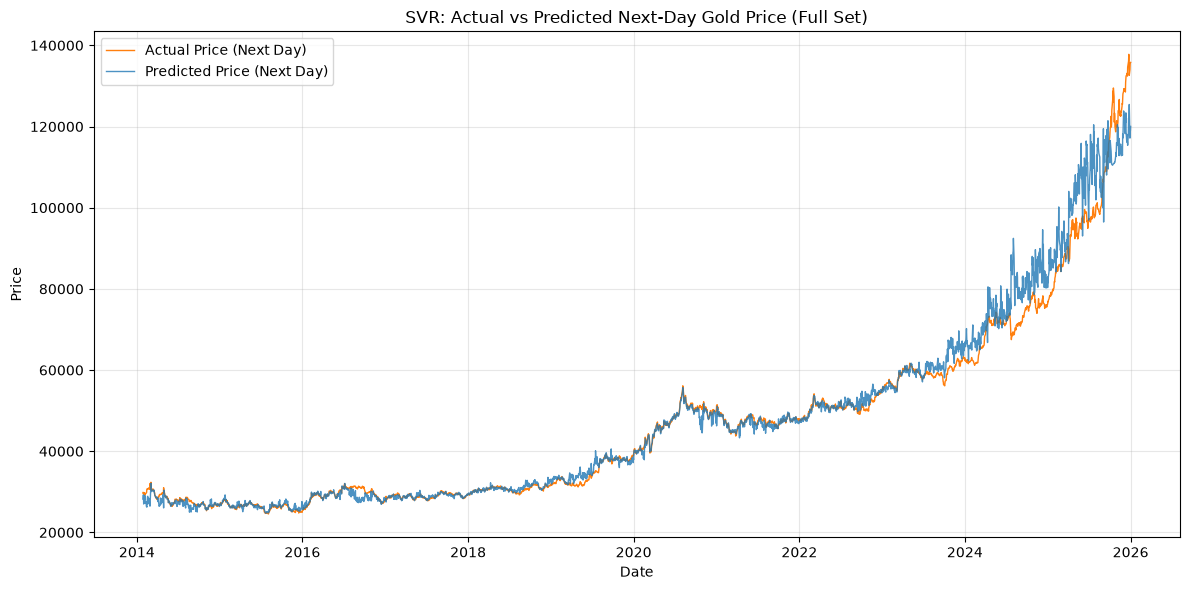

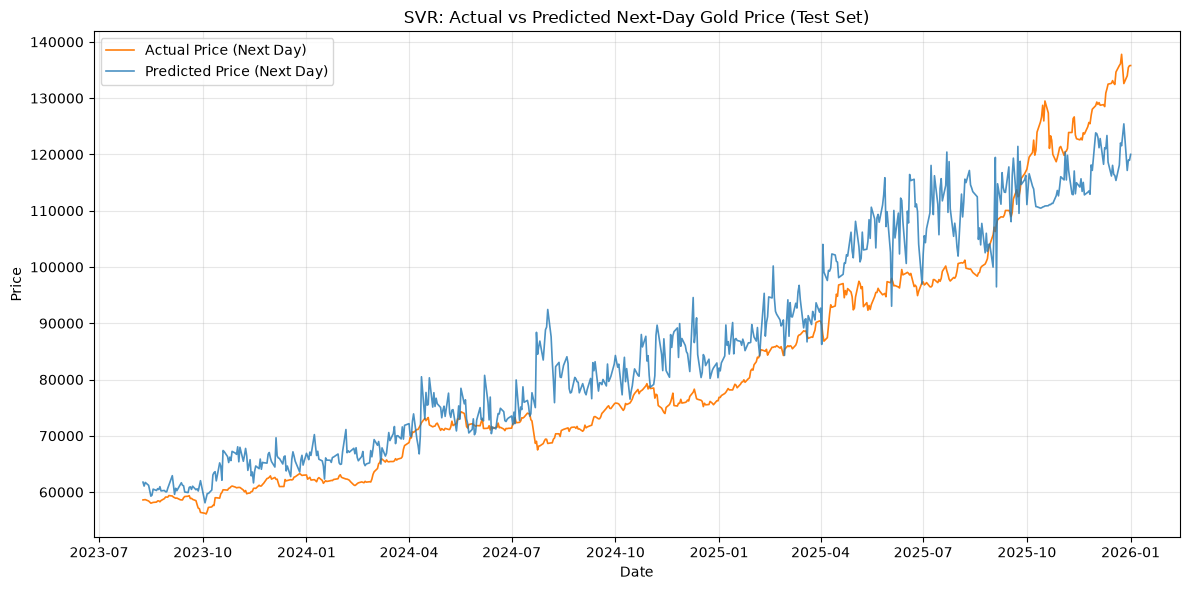

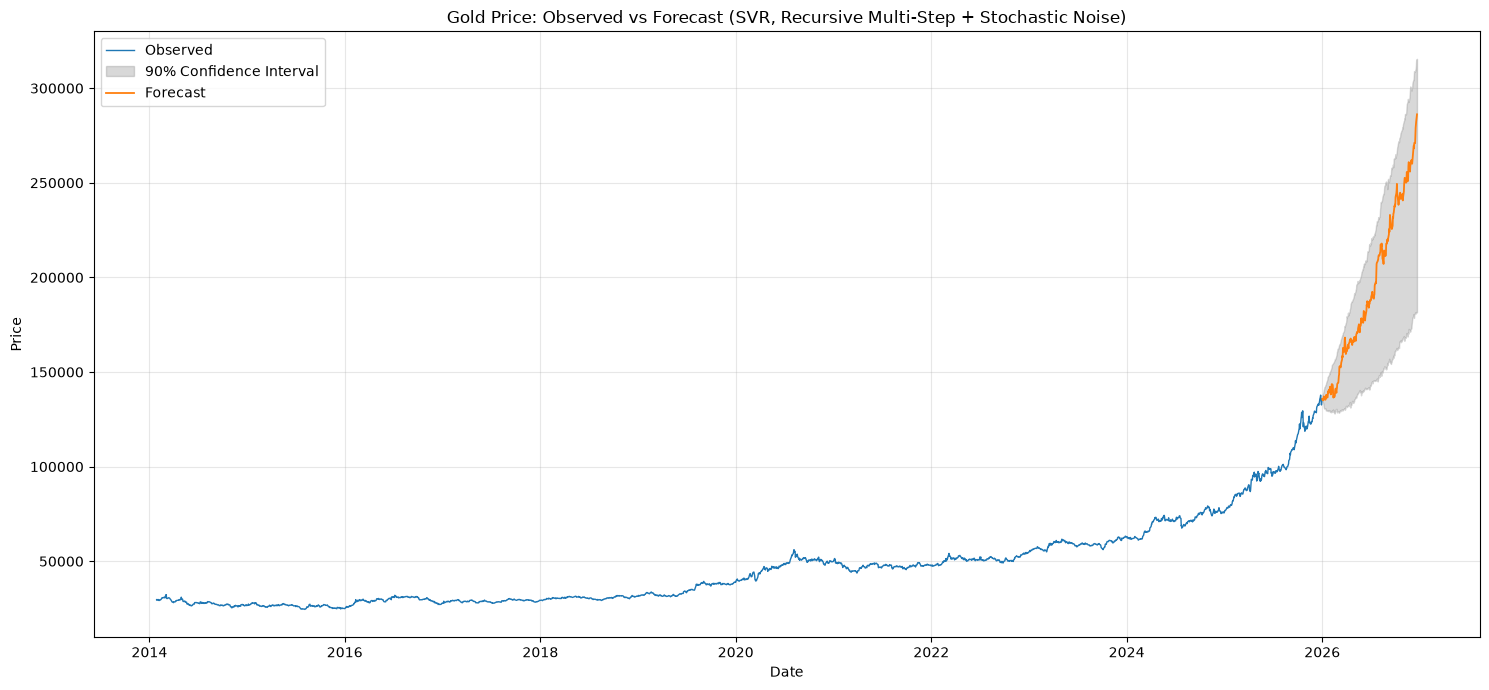

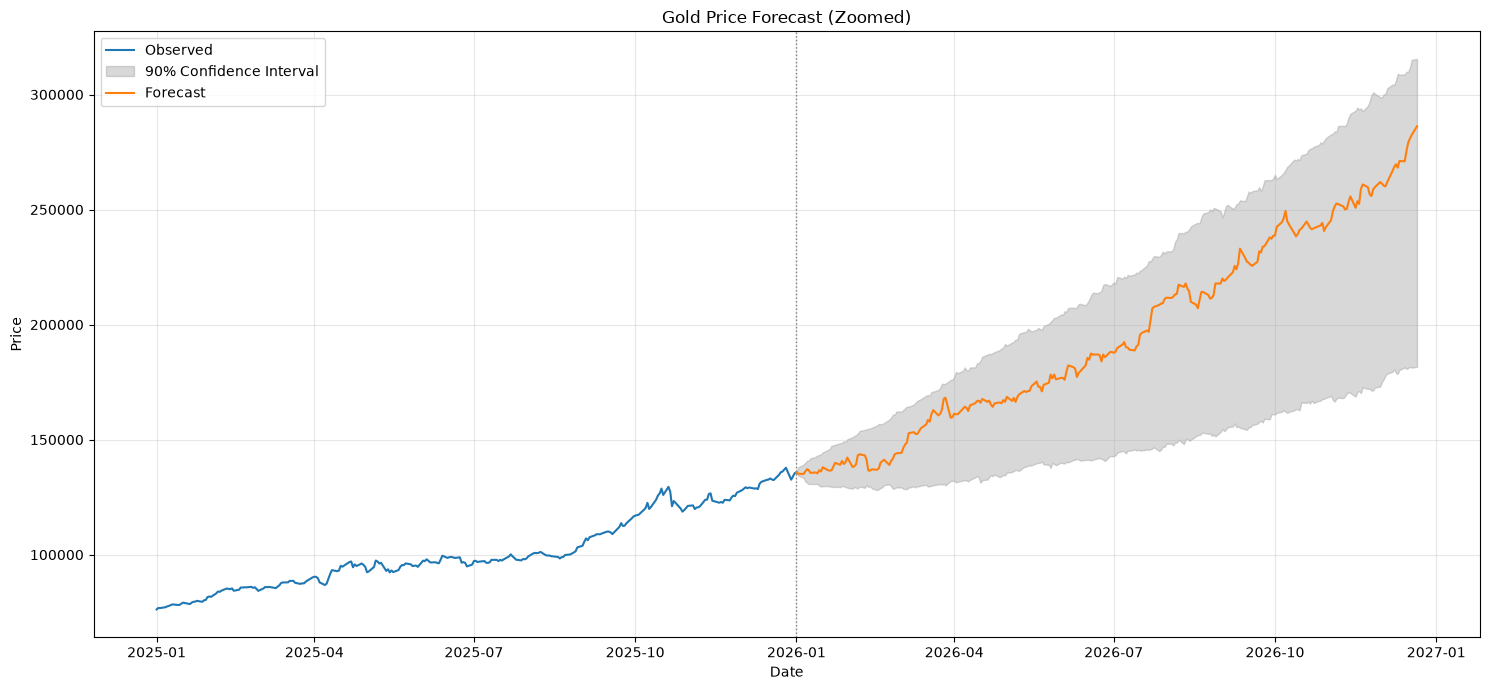

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Gold Price.csv")
pd.set_option('display.max_columns', None)

#########
# View the first 5 rows of the data

# Convert date format
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date (ensure correct chronological order)
df = df.sort_values('Date').reset_index(drop=True)


sns.histplot(df['Price'], kde=True, bins=50, color='#B8860B')
plt.title('Distribution of Gold Closing Price (Target Variable)')
plt.xlabel('Price')
plt.show()
plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['Price'], color='#888608')
plt.title('Gold Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (Target Variable)')
plt.show()

# 3. Time-based features
# 🔧 Year/Month/Day/Quarter kept for EDA/reporting only -- NOT part
# of feature_cols (models use DayOfWeek only, same as before).
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Quarter'] = df['Date'].dt.quarter

df['Return'] = df['Price'].pct_change()


df['Return_Today'] = df['Return']

for lag in [1, 2, 3, 5, 10]:
    df[f'Return_Lag_{lag}'] = df['Return'].shift(lag)

for window in [3, 5, 10, 20]:
    df[f'MA_{window}'] = df['Price'].rolling(window).mean()          # kept for transparency, not a model feature itself
    df[f'MA_Ratio_{window}'] = df['Price'] / df[f'MA_{window}'] - 1  # feature: % above/below the MA
    df[f'Vol_{window}'] = df['Return'].rolling(window).std()         # feature: rolling return volatility

df['Daily_Range_Pct'] = (df['High'] - df['Low']) / df['Low'] * 100
#
df['Price_Open_Ratio'] = df['Price'] / df['Open'] - 1

for lag in [1, 3, 5]:
    df[f'Volume_Lag_{lag}'] = df['Volume'].shift(lag)
df['Volume_MA_5'] = df['Volume'].rolling(5).mean()
df['Volume_MA_10'] = df['Volume'].rolling(10).mean()
df['Volume_Ratio'] = df['Volume'] / df['Volume_MA_10']

df['Target'] = df['Price'].shift(-1)          # next-day price (Model A / evaluation target)
df['Target_Return'] = df['Return'].shift(-1)  # next-day return (Model B / forecast-engine target)

feature_cols = [
    'DayOfWeek',
    'Return_Today',
    'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_10',
    'MA_Ratio_3', 'MA_Ratio_5', 'MA_Ratio_10', 'MA_Ratio_20',
    'Vol_3', 'Vol_5', 'Vol_10', 'Vol_20',
    'Daily_Range_Pct', 'Price_Open_Ratio',
    'Volume_Ratio', 'Volume_MA_5', 'Volume_MA_10',
    'Volume_Lag_1', 'Volume_Lag_3', 'Volume_Lag_5',
]
# 10. Outlier detection (IQR on Daily_Range_Pct) -- flag, don't drop
lo = df["Daily_Range_Pct"].quantile(0.25)
hi = df["Daily_Range_Pct"].quantile(0.75)
inter = hi - lo
lbound = lo - (inter * 1.5)
hbound = hi + (inter * 1.5)

out = df[(df["Daily_Range_Pct"] > hbound) | (df["Daily_Range_Pct"] < lbound)]

out_by_year = out.copy()
out_by_year['Year'] = pd.to_datetime(out_by_year['Date']).dt.year

df['Is_Extreme_Day'] = ((df['Daily_Range_Pct'] > hbound) |
                         (df['Daily_Range_Pct'] < lbound)).astype(int)

df_clean = df.dropna(subset=feature_cols).reset_index(drop=True)

# 12. Save the cleaned data -- SINGLE SOURCE OF TRUTH for all models
df_clean.to_csv('Gold_Price_Cleaned.csv', index=False)



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

np.random.seed(42)
t0 = time.time()

df = pd.read_csv("Gold_Price_Cleaned.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


feature_cols = [
    'DayOfWeek',
    'Return_Today',
    'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_10',
    'MA_Ratio_3', 'MA_Ratio_5', 'MA_Ratio_10', 'MA_Ratio_20',
    'Vol_3', 'Vol_5', 'Vol_10', 'Vol_20',
    'Daily_Range_Pct', 'Price_Open_Ratio',
    'Volume_Ratio', 'Volume_MA_5', 'Volume_MA_10',
    'Volume_Lag_1', 'Volume_Lag_3', 'Volume_Lag_5',
]
df_clean_A = df.dropna(subset=feature_cols + ['Target']).reset_index(drop=True)
df_clean_A['TimeIndex'] = np.arange(len(df_clean_A))

X_A = df_clean_A[feature_cols]
y_A = df_clean_A['Target']

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A, y_A, test_size=0.2, shuffle=False)
idx_train_A, idx_test_A = train_test_split(df_clean_A['TimeIndex'], test_size=0.2, shuffle=False)

log_price_train = np.log(y_train_A.values)
t_train = idx_train_A.values.reshape(-1, 1)
t_test = idx_test_A.values.reshape(-1, 1)

trend_lin = LinearRegression().fit(t_train, log_price_train)
trend_quad = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(t_train, log_price_train)
r2_lin = r2_score(log_price_train, trend_lin.predict(t_train))
r2_quad = r2_score(log_price_train, trend_quad.predict(t_train))
use_quad = r2_quad > r2_lin
trend_model = trend_quad if use_quad else trend_lin

log_trend_train = trend_model.predict(t_train)
log_trend_test = trend_model.predict(t_test)
target_detrended_train = log_price_train - log_trend_train
target_detrended_test = np.log(y_test_A.values) - log_trend_test


scaler_X_A = StandardScaler().fit(X_train_A)
X_train_A_scaled = scaler_X_A.transform(X_train_A)
X_test_A_scaled = scaler_X_A.transform(X_test_A)

scaler_y_A = StandardScaler().fit(target_detrended_train.reshape(-1, 1))
target_detrended_train_scaled = scaler_y_A.transform(target_detrended_train.reshape(-1, 1)).ravel()


eval_svr = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
eval_svr.fit(X_train_A_scaled, target_detrended_train_scaled)

pred_detrended_train_scaled = eval_svr.predict(X_train_A_scaled)
pred_detrended_test_scaled = eval_svr.predict(X_test_A_scaled)
pred_detrended_train = scaler_y_A.inverse_transform(pred_detrended_train_scaled.reshape(-1, 1)).ravel()
pred_detrended_test = scaler_y_A.inverse_transform(pred_detrended_test_scaled.reshape(-1, 1)).ravel()

pred_price_train = np.exp(pred_detrended_train + log_trend_train)
pred_price_test = np.exp(pred_detrended_test + log_trend_test)

def metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

train_mse, train_rmse, train_mae, train_r2 = metrics(y_train_A, pred_price_train, "BASELINE-TRAIN")
test_mse, test_rmse, test_mae, test_r2 = metrics(y_test_A, pred_price_test, "BASELINE-TEST")
naive_test_r2 = r2_score(y_test_A, np.exp(log_trend_test))

# ============================================================
# NAIVE PERSISTENCE BASELINE (predict tomorrow = today's closing price)
# ============================================================
naive_pred_train_A = df_clean_A.loc[X_train_A.index, 'Price'].values
naive_pred_test_A = df_clean_A.loc[X_test_A.index, 'Price'].values
naive_mse_tr_A, naive_rmse_tr_A, naive_mae_tr_A, naive_r2_tr_A = metrics(y_train_A, naive_pred_train_A, "NAIVE-TRAIN")
naive_mse_te_A, naive_rmse_te_A, naive_mae_te_A, naive_r2_te_A = metrics(y_test_A, naive_pred_test_A, "NAIVE-TEST")

# ============================================================
# 5-FOLD TIME SERIES CROSS-VALIDATION (BASELINE HYPERPARAMS)
# ============================================================
tscv = TimeSeriesSplit(n_splits=5)
cv_pipeline = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'))
cv_results = cross_validate(
    cv_pipeline,
    X_train_A, target_detrended_train,
    cv=tscv,
    scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
    return_train_score=False,
)

cv_r2 = cv_results["test_r2"]
cv_rmse = -cv_results["test_rmse"]
cv_df_A = pd.DataFrame({"fold": range(1, 6), "r2": cv_r2, "rmse_detrended": cv_rmse})
cv_df_A.to_csv("gold_svr_5fold_cv_results.csv", index=False)
# ============================================================
# HYPERPARAMETER TUNING (GridSearchCV)
# ============================================================\
tuning_pipeline = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
param_grid = {
    "svr__C": [0.1, 1, 10, 100],
    "svr__epsilon": [0.01, 0.1, 0.5],
    "svr__gamma": ["scale", "auto"],
}

tscv_search = TimeSeriesSplit(n_splits=3)
search_svr = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=tscv_search,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
search_svr.fit(X_train_A, target_detrended_train)
tuned_svr = search_svr.best_estimator_

pred_detrended_train_tuned = tuned_svr.predict(X_train_A)
pred_detrended_test_tuned = tuned_svr.predict(X_test_A)
pred_price_train_tuned = np.exp(pred_detrended_train_tuned + log_trend_train)
pred_price_test_tuned = np.exp(pred_detrended_test_tuned + log_trend_test)

train_mse_t, train_rmse_t, train_mae_t, train_r2_t = metrics(y_train_A, pred_price_train_tuned, "TUNED-TRAIN")
test_mse_t, test_rmse_t, test_mae_t, test_r2_t = metrics(y_test_A, pred_price_test_tuned, "TUNED-TEST")

# ============================================================
# RESULT COMPARISON -- BASELINE vs TUNED vs NAIVE
# ============================================================
comparison_df_svr = pd.DataFrame([
    {"Model": "Baseline SVR (manual params)", "Set": "Train", "MSE": train_mse, "RMSE": train_rmse, "MAE": train_mae, "R2": train_r2},
    {"Model": "Baseline SVR (manual params)", "Set": "Test", "MSE": test_mse, "RMSE": test_rmse, "MAE": test_mae, "R2": test_r2},
    {"Model": "Tuned SVR (GridSearchCV)", "Set": "Train", "MSE": train_mse_t, "RMSE": train_rmse_t, "MAE": train_mae_t, "R2": train_r2_t},
    {"Model": "Tuned SVR (GridSearchCV)", "Set": "Test", "MSE": test_mse_t, "RMSE": test_rmse_t, "MAE": test_mae_t, "R2": test_r2_t},
    {"Model": "Naive Persistence (tomorrow=today)", "Set": "Train", "MSE": naive_mse_tr_A, "RMSE": naive_rmse_tr_A, "MAE": naive_mae_tr_A, "R2": naive_r2_tr_A},
    {"Model": "Naive Persistence (tomorrow=today)", "Set": "Test", "MSE": naive_mse_te_A, "RMSE": naive_rmse_te_A, "MAE": naive_mae_te_A, "R2": naive_r2_te_A},
])
comparison_df_svr.to_csv("gold_svr_baseline_vs_tuned_vs_naive.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
plot_df_svr = comparison_df_svr[comparison_df_svr["Set"] == "Test"]
ax.bar(plot_df_svr["Model"], plot_df_svr["RMSE"], color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Test RMSE: Baseline vs Tuned SVR vs Naive Persistence")
ax.set_ylabel("RMSE (Price)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("svr_baseline_vs_tuned_vs_naive_rmse.png", dpi=200)
plt.show()

# ============================================================
# SCATTER + RESIDUAL PLOTS (train + test)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, y_true, y_pred, label, r2v, color in [
    (axes[0,0], y_train_A, pred_price_train, 'Train', train_r2, '#1f77b4'),
    (axes[0,1], y_test_A, pred_price_test, 'Test', test_r2, '#2ca02c')
]:
    ax.scatter(y_true, y_pred, alpha=0.4, s=12, color=color)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
    ax.set_title(f'{label}: Actual vs Predicted (R2={r2v:.4f})')
    ax.set_xlabel('Actual Price'); ax.set_ylabel('Predicted Price')
    ax.legend(); ax.grid(alpha=0.3)

resid_train_A = y_train_A.values - pred_price_train
resid_test_A = y_test_A.values - pred_price_test
axes[1,0].scatter(pred_price_train, resid_train_A, alpha=0.4, s=12, color='#1f77b4')
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_title('Train Residuals'); axes[1,0].set_xlabel('Predicted Price'); axes[1,0].set_ylabel('Residual')
axes[1,0].grid(alpha=0.3)
axes[1,1].scatter(pred_price_test, resid_test_A, alpha=0.4, s=12, color='#2ca02c')
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_title('Test Residuals'); axes[1,1].set_xlabel('Predicted Price'); axes[1,1].set_ylabel('Residual')
axes[1,1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('svr_overall_plot.png', dpi=200)
plt.show()

# ============================================================
# ACTUAL VS PREDICTED -- TIME SERIES LINE PLOTS
# ============================================================
X_A_scaled = scaler_X_A.transform(X_A)
pred_detrended_full_scaled = eval_svr.predict(X_A_scaled)
pred_detrended_full = scaler_y_A.inverse_transform(pred_detrended_full_scaled.reshape(-1, 1)).ravel()
log_trend_full = trend_model.predict(df_clean_A['TimeIndex'].values.reshape(-1, 1))
pred_price_full = np.exp(pred_detrended_full + log_trend_full)

plt.figure(figsize=(12, 6))
plt.plot(df_clean_A['Date'], df_clean_A['Target'], label='Actual Price (Next Day)', color='#ff7f0e', linewidth=1)
plt.plot(df_clean_A['Date'], pred_price_full, label='Predicted Price (Next Day)', color='#1f77b4', linewidth=1, alpha=0.8)
plt.title('SVR: Actual vs Predicted Next-Day Gold Price (Full Set)')
plt.xlabel('Date'); plt.ylabel('Price')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('svr_actual_vs_predicted_fullset_line.png', dpi=200)
plt.show()

test_dates_A = df_clean_A.loc[X_test_A.index, 'Date']
plt.figure(figsize=(12, 6))
plt.plot(test_dates_A, y_test_A.values, label='Actual Price (Next Day)', color='#ff7f0e', linewidth=1.2)
plt.plot(test_dates_A, pred_price_test, label='Predicted Price (Next Day)', color='#1f77b4', linewidth=1.2, alpha=0.8)
plt.title('SVR: Actual vs Predicted Next-Day Gold Price (Test Set)')
plt.xlabel('Date'); plt.ylabel('Price')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('svr_actual_vs_predicted_testset_line.png', dpi=200)
plt.show()

# ============================================================
# MODEL B: RETURN-BASED TARGET (forecast engine)
# ============================================================
df_feat_B = df.reset_index(drop=True)
df_clean_B = df_feat_B.dropna(subset=['Target_Return']).reset_index(drop=True)

X_B = df_clean_B[feature_cols]
y_B = df_clean_B['Target_Return']

X_train_B = X_B.iloc[:int(len(X_B) * 0.8)]
y_train_B = y_B.iloc[:int(len(y_B) * 0.8)]
X_test_B = X_B.iloc[int(len(X_B) * 0.8):]
y_test_B = y_B.iloc[int(len(y_B) * 0.8):]

scaler_X_B_eval = StandardScaler().fit(X_train_B)
scaler_y_B_eval = StandardScaler().fit(y_train_B.values.reshape(-1, 1))

eval_svr_B = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
eval_svr_B.fit(
    scaler_X_B_eval.transform(X_train_B),
    scaler_y_B_eval.transform(y_train_B.values.reshape(-1, 1)).ravel()
)
pred_test_B_scaled = eval_svr_B.predict(scaler_X_B_eval.transform(X_test_B))
pred_test_B = scaler_y_B_eval.inverse_transform(pred_test_B_scaled.reshape(-1, 1)).ravel()
residuals = y_test_B.values - pred_test_B

hist_mean_return = df_clean_B['Return'].mean()

scaler_X_B_final = StandardScaler().fit(X_B)
scaler_y_B_final = StandardScaler().fit(y_B.values.reshape(-1, 1))
final_svr = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
final_svr.fit(
    scaler_X_B_final.transform(X_B),
    scaler_y_B_final.transform(y_B.values.reshape(-1, 1)).ravel()
)
# ============================================================
# RECURSIVE MULTI-STEP + STOCHASTIC NOISE SIMULATION
# ------------------------------------------------------------
# Each simulated path is built one trading day at a time:
#   1. Feed the current feature row into the SVR -> predicted return
#   2. Blend it toward the historical mean return as the horizon
#      grows (dampening), since the model's edge decays the further
#      out it forecasts
#   3. Add stochastic noise (bootstrapped from real out-of-sample
#      residuals) to represent the model's normal day-to-day error
#   4. Turn the noisy return into a new price, and rebuild every lag/
#      moving-average/volatility feature from that new price so the
#      next step's prediction is conditioned on the simulated past,
#      not the real one (this is what makes it "recursive")
# Doing this for N_SIMULATIONS paths at once (vectorized over rows)
# gives a distribution of possible futures -> confidence band.
# ============================================================
HORIZON_DAYS = 252
N_SIMULATIONS = 300
DAMPEN_HALF_LIFE = 250  # trading days for momentum to fade toward historical mean
MAXLAG = 10

col = {c: i for i, c in enumerate(feature_cols)}


def build_next_features(price_hist, return_hist, volume_hist, new_prices, high_new, low_new,
                         open_new, volume_new, fdate, feature_cols, col):
    """Recompute one day's feature row from the simulated (not real) history so far."""
    n_paths = price_hist.shape[0]
    new_feat = np.zeros((n_paths, len(feature_cols)))
    new_feat[:, col['DayOfWeek']] = fdate.dayofweek
    new_feat[:, col['Return_Today']] = return_hist[:, -1]
    for lag in [1, 2, 3, 5, 10]:
        new_feat[:, col[f'Return_Lag_{lag}']] = return_hist[:, -lag]
    for window in [3, 5, 10, 20]:
        ma = price_hist[:, -window:].mean(axis=1)
        new_feat[:, col[f'MA_Ratio_{window}']] = new_prices / ma - 1
        new_feat[:, col[f'Vol_{window}']] = return_hist[:, -window:].std(axis=1, ddof=1)
    new_feat[:, col['Daily_Range_Pct']] = (high_new - low_new) / low_new * 100
    new_feat[:, col['Price_Open_Ratio']] = new_prices / open_new - 1
    vol_ma10 = volume_hist[:, -10:].mean(axis=1)
    new_feat[:, col['Volume_Ratio']] = volume_new / vol_ma10
    for lag in [1, 3, 5]:
        new_feat[:, col[f'Volume_Lag_{lag}']] = volume_hist[:, -lag]
    new_feat[:, col['Volume_MA_5']] = volume_hist[:, -5:].mean(axis=1)
    new_feat[:, col['Volume_MA_10']] = vol_ma10
    return new_feat


def recursive_multistep_forecast(model, scaler_X, scaler_y, df_clean_B, feature_cols, col,
                                  residual_pool, hist_mean_return, horizon_days, n_paths,
                                  dampen_half_life, maxlag, base_seed=7):
    """
    Recursive multi-step forecast with stochastic noise, vectorized across
    n_paths simulated futures. Returns:
      all_paths : (n_paths, horizon_days) simulated price paths
      future_dates : the business-day dates for each forecasted step
    """
    last_actual_date = df_clean_B['Date'].max()
    future_dates = pd.bdate_range(start=last_actual_date + pd.Timedelta(days=1), periods=horizon_days)

    hist_len0 = maxlag + 10
    price_hist = np.tile(df_clean_B['Price'].values[-hist_len0:], (n_paths, 1)).astype(float)
    return_hist = np.tile(df_clean_B['Return'].values[-hist_len0:], (n_paths, 1)).astype(float)
    volume_hist = np.tile(df_clean_B['Volume'].values[-hist_len0:], (n_paths, 1)).astype(float)
    avg_range_pct = df_clean_B['Daily_Range_Pct'].tail(60).mean()

    base_row = df_feat_B.iloc[-1][feature_cols].values.astype(float)
    feat_matrix = np.tile(base_row, (n_paths, 1))

    rng = np.random.default_rng(base_seed)
    all_paths = np.zeros((n_paths, horizon_days))

    for step in range(horizon_days):
        # --- Step 1: model's raw predicted return for every path ---
        feat_scaled = scaler_X.transform(pd.DataFrame(feat_matrix, columns=feature_cols))
        raw_pred_scaled = model.predict(feat_scaled)
        raw_pred_returns = scaler_y.inverse_transform(raw_pred_scaled.reshape(-1, 1)).ravel()

        # --- Step 2: dampen the forecast toward the historical mean return ---
        dampen_weight = 0.5 ** (step / dampen_half_life)
        blended_returns = raw_pred_returns * dampen_weight + hist_mean_return * (1 - dampen_weight)

        # --- Step 3: inject stochastic noise (bootstrapped residuals) ---
        noise = rng.choice(residual_pool, size=n_paths, replace=True)
        combined_returns = blended_returns + noise

        # --- Step 4: turn the noisy return into a new simulated price ---
        new_prices = price_hist[:, -1] * (1 + combined_returns)
        all_paths[:, step] = new_prices

        fdate = future_dates[step]
        open_new = price_hist[:, -1].copy()
        half_range_pct = avg_range_pct / 2 / 100
        high_new = np.maximum(open_new * (1 + half_range_pct), new_prices)
        low_new = np.minimum(open_new * (1 - half_range_pct), new_prices)
        volume_new = volume_hist[:, -10:].mean(axis=1)

        # extend the simulated history so the NEXT step's features are
        # built from what we just simulated, not the real historical data
        price_hist = np.concatenate([price_hist, new_prices[:, None]], axis=1)
        return_hist = np.concatenate([return_hist, combined_returns[:, None]], axis=1)
        volume_hist = np.concatenate([volume_hist, volume_new[:, None]], axis=1)

        feat_matrix = build_next_features(
            price_hist, return_hist, volume_hist, new_prices, high_new, low_new,
            open_new, volume_new, fdate, feature_cols, col
        )


    return all_paths, future_dates


all_paths, future_dates = recursive_multistep_forecast(
    model=final_svr,
    scaler_X=scaler_X_B_final,
    scaler_y=scaler_y_B_final,
    df_clean_B=df_clean_B,
    feature_cols=feature_cols,
    col=col,
    residual_pool=residuals,
    hist_mean_return=hist_mean_return,
    horizon_days=HORIZON_DAYS,
    n_paths=N_SIMULATIONS,
    dampen_half_life=DAMPEN_HALF_LIFE,
    maxlag=MAXLAG,
    base_seed=7,
)

last_actual_date = df_clean_B['Date'].max()
display_path = all_paths[0]
p05 = np.percentile(all_paths, 5, axis=0)
p95 = np.percentile(all_paths, 95, axis=0)
p50 = np.percentile(all_paths, 50, axis=0)

forecast_df = pd.DataFrame({
    'Date': future_dates, 'Forecast_Path': display_path,
    'Median': p50, 'Lower_5%': p05, 'Upper_95%': p95
})
forecast_df.to_csv('gold_price_forecast_svr_montecarlo.csv', index=False)
# ============================================================
# CHARTS
# ============================================================
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(df_clean_B['Date'], df_clean_B['Price'], color='#1f77b4', linewidth=1, label='Observed')
connector_date = pd.concat([pd.Series([last_actual_date]), forecast_df['Date']], ignore_index=True)
connector_path = np.concatenate([[df_clean_B['Price'].iloc[-1]], display_path])
connector_p05 = np.concatenate([[df_clean_B['Price'].iloc[-1]], p05])
connector_p95 = np.concatenate([[df_clean_B['Price'].iloc[-1]], p95])
ax.fill_between(connector_date, connector_p05, connector_p95, color='gray', alpha=0.3, label='90% Confidence Interval')
ax.plot(connector_date, connector_path, color='#ff7f0e', linewidth=1.3, label='Forecast')
ax.set_title('Gold Price: Observed vs Forecast (SVR, Recursive Multi-Step + Stochastic Noise)')
ax.set_xlabel('Date'); ax.set_ylabel('Price')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svr_montecarlo_forecast.png', dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(15, 7))
zoom_start = last_actual_date - pd.Timedelta(days=365)
zoom_actual = df_clean_B[df_clean_B['Date'] >= zoom_start]
ax.plot(zoom_actual['Date'], zoom_actual['Price'], color='#1f77b4', linewidth=1.5, label='Observed')
ax.fill_between(connector_date, connector_p05, connector_p95, color='gray', alpha=0.3, label='90% Confidence Interval')
ax.plot(connector_date, connector_path, color='#ff7f0e', linewidth=1.5, label='Forecast')
ax.axvline(last_actual_date, color='gray', linestyle=':', linewidth=1)
ax.set_title('Gold Price Forecast (Zoomed)')
ax.set_xlabel('Date'); ax.set_ylabel('Price')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svr_montecarlo_forecast_zoomed.png', dpi=200)
plt.show()
